# R01 - Schwinger Effect Persistence Analysis

**Author**: oscar-vbl
**Project:** `Lattice-QFT-Quantum-Simulation`  
**Version:** v1

## Summary
This notebook shows a full quantum simulation of the (1+1) QED Schwinger model for several values of L with the software developed on the repository Lattice-QFT-Quantum-Simulation.

The simulations have been performed without a backend, although the repository allows to run the simulations on NISQ hardware.

Each simulation is performed calling the script SchwingerSimulation.py, with the following steps:
1. **Creation of the Hamiltonian**: The Hamiltonian is created with the given parameters.
2. **State Preparation (VQE)**: An `ExcitationPreserving` qiskit ansatz is optimized via L-BFGS-B to prepare vacuum ground state.
3. **Quench**: The background field $\varepsilon_0$ is turned on for $t>0$.
4. **Time evolution (Trotterization)**: A second order Trotter-Suzuki evolution gate is applied at each temporal step of the simulation, saving the expectation values of different observables during evolution.

Later, the results of the simulations have been analyzed and some results related with vacuum persistance have been calculated.

This is an updated version of the original document, with calculations refined.


## Theoretical Framework: The Schwinger Model on a Lattice
The Schwinger model describes QED in 1+1 dimensions. It has been widely studied as a paradigmatic model in High Energy Physics because, although its simplicity, it shows some non-perturbative phenomena.

To simulate it on a quantum computer, we have used the Kogut-Sussking formulation with staggered fermions, which allows us to transform the fermionic degrees of freedom to a spin chain of $L$ sites through the Jordan-Wigner transform. We are used the temporal gauge $(A_0=0)$, with the hamiltonian as

$$H = w \sum_{n=1}^{L-1} \left[ \sigma^+_n \sigma^-_{n+1} + \sigma^-_n \sigma^+_{n+1} \right] + \frac{m}{2} \sum_{n=1}^L (-1)^n \sigma^z_n + J \sum_{n=1}^{L-1} L_n^2,$$

where its parameters are
 - a: Lattice spacing.
 - m: Bare mass of the fermions.
 - $w=1/(2a)$: Hopping amplitude.
 - $J=e^2a/2$: Electric field energy with coupling constant $e$.
 - $L_n$: Electric field operator at site $n$, defined by Gauss' law.

In this gauge, Gauss' law is a constrait of the dynamics, defined as

$$L_n - L_{n-1} = q_n,$$

where the charge operator at site $n$ is

$$q_n = \frac{1}{2} \left( \sigma_n^z + (-1)^n\right)$$

and $L_n$ can be expressed as

$$L_n = \varepsilon_0 + \sum_{k=1}^n q_k,$$

being $\varepsilon_0$ the background field on the link at the left of the first lattice site.

This imposes the following restriction over the Gauss' operator $g_n$:

$$g_n = L_n - L_{n-1} - q_n = 0.$$

From now on, we are using natural units such that $e=1$.

## Vacuum Instability and Persistence Amplitude

The main phenomenon we are studying in this notebook is the response of the vacuum to a quantum quench.

We prepare the ground state $|\text{vac}\rangle$ of a hamiltonian with null background field $\varepsilon_0$ and study its evolution under a hamiltonian where $\varepsilon_0$ has been activated.

The main quantity we are going to track is the vacuum persistence probability (also known as Loschmidt Echo), $G(t)$, which is the probability that the state remains in the initial state after a time $t$:

$$G(t) = |\langle \psi (0) | \psi (t) \rangle | ^2 = |\langle \text{vac} | e^{-iHt} | \text{vac} \rangle | ^2.$$

In the thermodynamic limit, we expect this probability to decay exponentially due to creation of pairs electron-positron that destroy original vacuum:

$$G(t) \propto \exp(-\Gamma t),$$

where $\Gamma$ is the rate of production of pairs, and $\gamma = \frac{d\Gamma}{dV}$ the rate of pair production per unit volume.

Theoretical decay rate per unit volume was deduced by Julian Schwinger (1951):

$$\gamma_{th} = \frac{E}{2\pi} \exp \left( -\frac{\pi m^2}{E} \right).$$

In [1]:
%matplotlib inline
import sys
import numpy as np
import copy
from pathlib import Path
import matplotlib

print(matplotlib.__version__)
import matplotlib_inline

print(matplotlib_inline.__version__)
import matplotlib.pyplot as plt

sys.path.append(Path.cwd().parent.as_posix())
from QuantumSimulation.ResultsAnalysis import fit_persistence
from QuantumSimulation.Utils import loadJsonConfig, parseDictToPlot
from QuantumSimulation.Plots import (
    plot_gamma_vs_qubitNum,
    plot_persistenece_vs_time_regimes,
    plot_gamma_vs_e0,
    plot_gamma_vs_electricField,
)
from R00_ResultsCommon import get_simulation_data, load_simulator_instance, load_evolution_and_initial
from R01_Persistence import fit_persistence_e0, fit_persistence_qubits_num, _get_simulator_data, _build_total_sigma, _load_ideal_evolution_data

3.10.8
0.2.1


## Config-Driven Simulation Setup
To ensure reproducibility and CI/CD compatibility, the simulation engine is entirely driven by a JSON configuration file (`SchwingerSimulation_Persistence_v2.json`). This strictly separates the physical parameters ($L, m, a$), the backend execution layer, algorithmic choices and parameters of temporal evolution.

In [2]:
# Load Config
config = loadJsonConfig("SchwingerSimulation_Persistence_v2.json")

# Set to False if you want to run all simulations from scratch
# True to load previously simulated data (if available) or run simulation if not found.
USE_SIMULATED_DATA = True

## 1. Get evolution data for different values of L

This cell generates a plot of vacuum persistance (simulated and analytical) against the number of qubits.

Maximum and minimum number of qubits have to be set at the beginning.

We will sweep across different lattice sizes ($L$) to study Finite-Size Effects.


1. Γ vs number of qubits — finite-size scaling

INFO: Best qubit number: 18


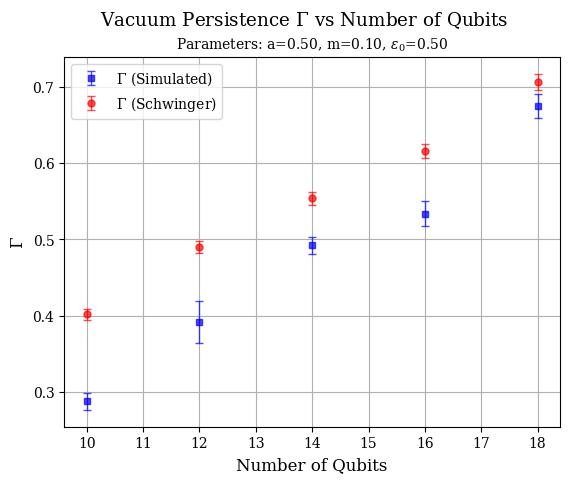

In [3]:
# ═══════════════════════════════════════════════════════════════════════
# 1. Γ vs number of qubits — finite-size scaling
# ═══════════════════════════════════════════════════════════════════════
print("\n1. Γ vs number of qubits — finite-size scaling\n")
analysis_name    = "01_Persistence_Noisy_Data"
file_name        = "01_01_DecayRate_vs_QubitsNum"
min_qubit_num, max_qubit_num, step = 10, 18, 2
qubit_num_values = np.arange(min_qubit_num, max_qubit_num + step, step)
qubit_num_values = np.array([int(qubit_num) for qubit_num in qubit_num_values])

# Load ideal evolution data for comparision with noisy
ideal_qubits_num_data = _load_ideal_evolution_data(qubit_num_values, config,
                                                           use_simulated_data=USE_SIMULATED_DATA)
vqe_initial_states = {
    qubits_num: ideal_qubits_num_data[qubits_num]["initial_state"]
    for qubits_num in qubit_num_values
}

# Load .pkl simulator instances (one per L)
qubits_num_simulators = load_simulator_instance(
    analysis_name,
    qubit_num_values,
    simulator_file_template="Sim_Instance_{value}_Qubits.pkl",
    backup_config=config,
    backup_key="L",
    use_simulated_data=USE_SIMULATED_DATA,
    initial_states=vqe_initial_states
)

fit_results_df = fit_persistence_qubits_num(
    config, qubit_num_values, qubits_num_simulators
)

plot_params = parseDictToPlot(
    {
        **config["Hamiltonian"]["Parameters"],
        **config["Temporal Evolution"]["Quench"]["Parameters_to_Change"],
    },
    remove_keys=["L"],
    rename_keys={"e0": "$\\varepsilon_0$"},
)
fig, ax = plot_gamma_vs_qubitNum(fit_results_df, params=plot_params)

# Find best L (minimum deviation to analytical)
fit_results_df["Deviation"] = np.abs(
    1 - fit_results_df["Gamma_Analytical"] / fit_results_df["Gamma_Simulated"]
)
best_qubit_num = int(fit_results_df["Deviation"].idxmin())
print(f"INFO: Best qubit number: {best_qubit_num}")

plt.show()

## 2. Show best fit

Once we have the best qubit number on the cell above (the one with the lowest deviation between the analytical and simulated value), we focus on it studying the quench dynamics, how the vacuum persistence probability decays over time.

We implement a custom 1st/2nd derivative cutoff algorithm to strictly isolate the pure exponential decay regime. This systematically removes:
1. Early-time artifacts (Quantum Zeno effect).
2. Late-time artifacts (Finite-size boundary revivals).

On the exponential regime, we have plotted the results of the simulation and the Schwinger prediction, which is computed by:

$$\Gamma = \int dx \ \gamma(x), \ \gamma(x) = \frac{E(x)}{2\pi} \exp\left(-\frac{\pi m^2}{E(x)}\right),$$

with the lattice version calculated as

$$\Gamma \approx \sum_n^L a \gamma_n = \sum_n^L a \gamma (E_n),$$

where $E_n$ is the electric field in the site $n$, $E_n = \varepsilon_0 + \sum_{k=0}^n q_k$.


2. Best fit — exponential decay plot with error band

2026-07-30 19:13:33 INFO: Parameters of the hamiltonian to check regime:
    w = 1.00  (hopping)
    J = 0.2500  (gauge coupling)
    w/J = 4.0  (must be O(1) for non trivial physics)
    eE/πm² = 15.92  (must be >> 1)
    L_phys·M_S = 4.80  (must be >> 1)
    eE·a = 0.250  (must be << 1 for continous limit)
2026-07-30 19:13:33 INFO: Γ (simulated):  0.6743 ± 0.0155
2026-07-30 19:13:33 INFO: Γ (analytical): 0.7063
2026-07-30 19:13:33 INFO: Deviation: 4.5%
2026-07-30 19:13:33 INFO: log-linear slope: -0.6898
2026-07-30 19:13:33 INFO: R² of linear fit: 0.9902
2026-07-30 19:13:33 INFO: log-linear slope: -0.6743
2026-07-30 19:13:33 INFO: R² of linear fit: 0.9928


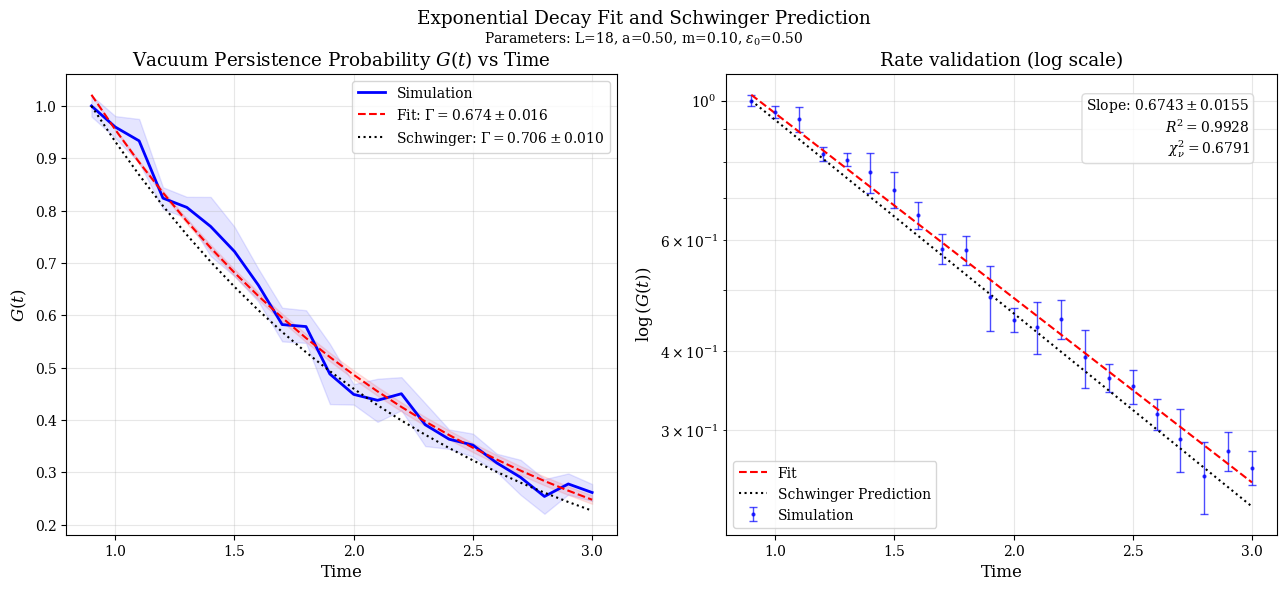

In [4]:
print("\n2. Best fit — exponential decay plot with error band\n")

analysis_name = f"01_02_BestDecayRate_vs_QubitsNum"
file_name     = f"01_02_BestDecayRate_vs_QubitsNum"

best_simulator = qubits_num_simulators[best_qubit_num]["simulator"]
evolution_data, evolution_error, initial_state, trotter_error = \
    _get_simulator_data(best_simulator)
sigma = _build_total_sigma(evolution_data, evolution_error, trotter_error)

best_config = copy.deepcopy(
    getattr(best_simulator, "config", config)
)
best_config["QubitsNumber"] = best_qubit_num
best_config["Hamiltonian"]["Parameters"]["L"] = best_qubit_num

fig, axes = fit_persistence(
    evolution_data,
    best_config,
    initial_state,
    sigma=sigma,
    evolution_error=evolution_error,
    use_offset=False,
    return_plot=True,
)
# Show fig
plt.show()

## 3. Plot persistence and regimes for best fit

For the best fit, the full evolution of vacuum persistence is plotted, with the different regimes outlined.


3. Persistence vs time — full evolution with regimes



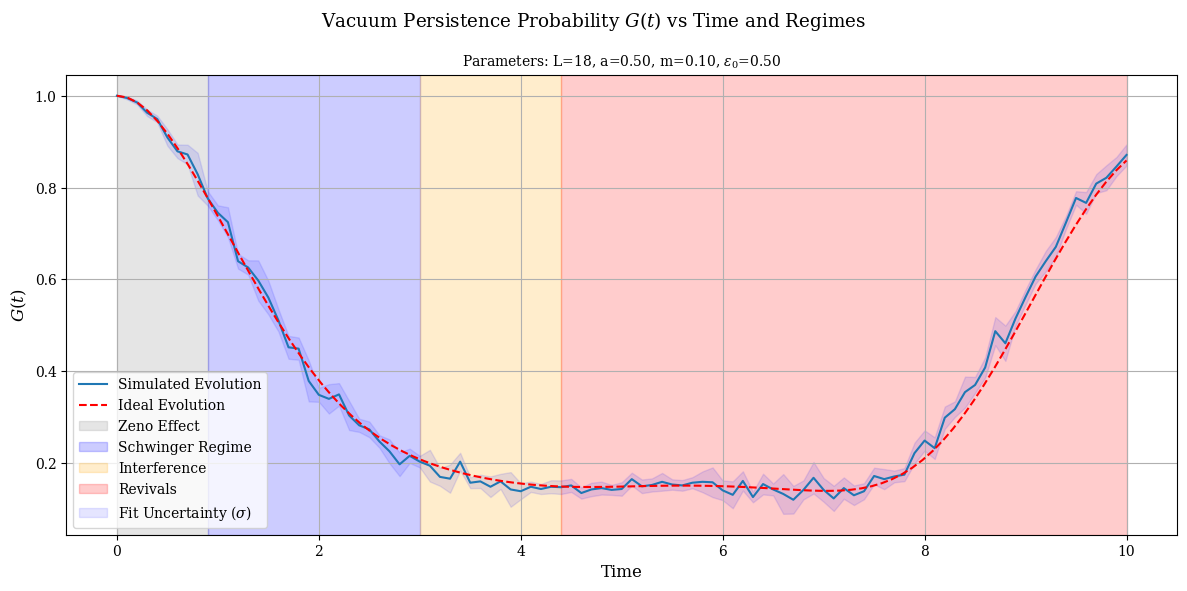

In [5]:
print("\n3. Persistence vs time — full evolution with regimes\n")

analysis_name = f"01_03_Persistence_vs_Time"
file_name     = f"01_03_Persistence_vs_Time"

cut_off_times = fit_results_df.loc[best_qubit_num, "Cut_Off_Times"]
plot_params   = parseDictToPlot(
    {
        **best_config["Hamiltonian"]["Parameters"],
        **best_config["Temporal Evolution"]["Quench"]["Parameters_to_Change"],
    },
    remove_keys=[],
    rename_keys={"e0": "$\\varepsilon_0$"},
)

# Pass error band (total sigma) to the regime plot if supported
fig, ax = plot_persistenece_vs_time_regimes(
    evolution_data,
    cut_off_times,
    plot_params,
    sigma=sigma,          # band on the persistence curve
    ideal_evolution_data=ideal_qubits_num_data.get(best_qubit_num, {}).get("evolution_data"),
)
# Show fig
plt.show()

## 4. Show best fit for different values of $\varepsilon_0$

We analyze how the vaccum persistence varies for different values of $\varepsilon_0$.

The comparison between the simulated vacuum decay rate ($\Gamma$) and the continuous analytical formula reveals three distinct physical regimes driven by finite-size and lattice artifacts:

* **Weak Field Regime** ($\epsilon_0 \lesssim 0.4$): Simulated rates fall significantly below theoretical predictions. The discrete momentum quantization in a finite lattice ($L=20$) creates a threshold barrier that suppresses quantum tunneling for weak fields.
* **Continuous Limit Agreement ($\epsilon_0 \approx 0.4 - 0.6$):** The field is strong enough to overcome discretization artifacts, but weak enough to avoid immediate edge collisions. In this window (relative error $< 20\%$), the lattice accurately emulates the continuous continuum limit. Persistence follows a straight with a slope higher than the analytical one (explained on the cell below).
* **Strong Field Divergence ($\epsilon_0 \gtrsim 0.7$):** The analytical approximation collapses, because the fast acceleration of particles causes immediate collisions with the spatial boundaries. Furthermore, extreme field tension triggers non-linear multi-pair cascades and Bloch oscillations, visible as the "steps" around $\epsilon_0 \approx 0.8 - 0.9$.


4. Γ vs ε₀ sweep



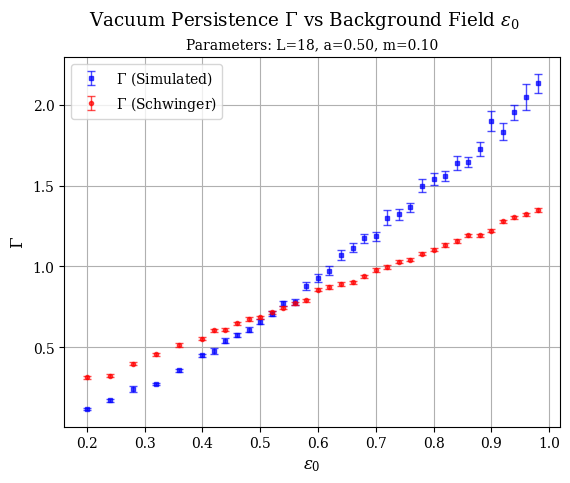

In [6]:
print("\n4. Γ vs ε₀ sweep\n")

qubits_num    = best_qubit_num
analysis_name = f"01_04_Gamma_vs_E0"
file_name     = f"01_04_Gamma_vs_E0"

# Weak field regime
e0_values = np.arange(0.20, 0.36 + 0.04, 0.04)
# Schwinger + strong field regime
e0_values = np.concatenate((e0_values, np.arange(0.40, 0.98 + 0.02, 0.02)))

# Load one simulator per e0 value
# The initial state is the same for all (e0 is quenched, not a prep param)
e0_simulators = load_simulator_instance(
    analysis_name,
    e0_values,
    simulator_file_template="Sim_Instance_e0_{value}"+f"_{best_qubit_num}_Qubits.pkl",
    backup_config=best_config,
    backup_key="e0",
    backup_key_is_quench=True,
    use_simulated_data=USE_SIMULATED_DATA,
    initial_states={e0: vqe_initial_states[best_qubit_num] for e0 in e0_values}
)

fit_results_df = fit_persistence_e0(best_config, e0_values, e0_simulators)

plot_params = parseDictToPlot(
    best_config["Hamiltonian"]["Parameters"],
    remove_keys=["e0"],
    rename_keys={},
)
fig, ax = plot_gamma_vs_e0(fit_results_df, params=plot_params)
# Show fig
plt.show()

## 5. Plot $\log\left(\frac{\Gamma}{\varepsilon_0}\right)$ vs $\frac{1}{\varepsilon_0}$ for Schwinger regime

The analytical Schwinger formula predicts a non-perturbative, tunneling-like decay rate:
$$\Gamma \propto E \exp\left(-\frac{\pi m_{\text{eff}}^2}{E}\right)$$

If the quantum simulation successfully captures this non-perturbative regime, plotting $\ln(\Gamma / \langle E_n \rangle)$ against $1 / \langle E_n \rangle$ will yield a **straight line**. 
Furthermore, the slope of this line is directly proportional to $-\pi m_{\text{eff}}^2$, allowing us to extract the **dressed (renormalized) mass** of the particles generated dynamically by the lattice interactions.

We use the measured physical electric field $\langle E_n \rangle$ (dynamically generated by the state) rather than the bare parameter $\varepsilon_0$ to account for vacuum polarization.

The linear regression perfectly captures the tunneling signature. From the slope, we extract an effective dressed mass of **$m_{\text{eff}} \approx 0.418$**. 

Due to lattice interactions and vacuum polarization, the "bare" mass parameter ($m_{\text{bare}} = 0.1$) fed into the Hamiltonian is dynamically renormalized. The simulated particles are significantly heavier than their bare parameters suggest.


5. log(Γ/⟨E⟩) vs 1/⟨E⟩ — non-perturbative Schwinger signature



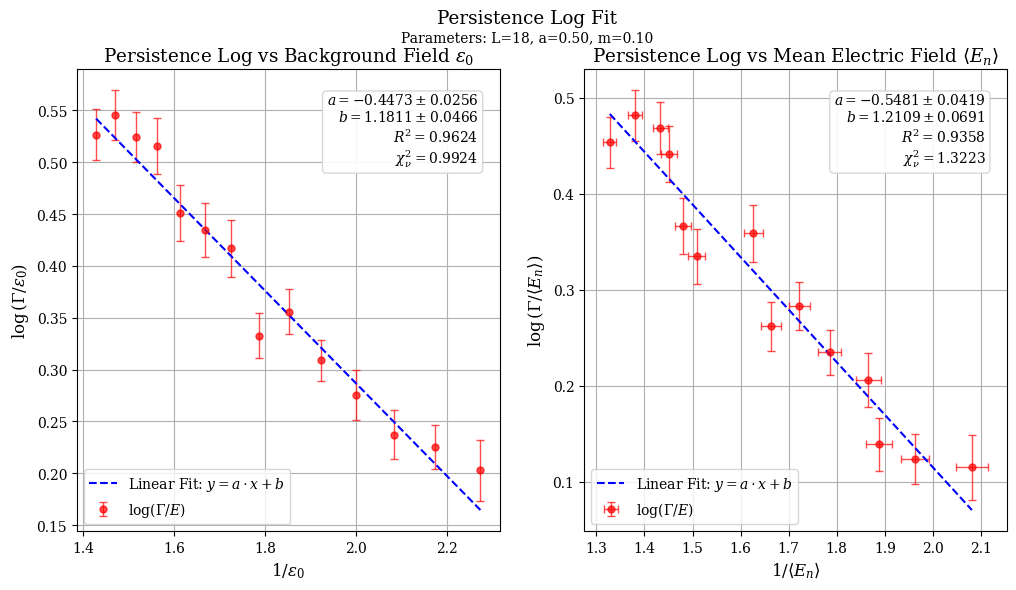

In [7]:
print("\n5. log(Γ/⟨E⟩) vs 1/⟨E⟩ — non-perturbative Schwinger signature\n")

analysis_name = f"01_05_LogPersistence_vs_ElectricField"
file_name     = f"01_05_LogPersistence_vs_ElectricField"

# Filter to Schwinger regime (deviation ≤ 20 %)
max_deviation = 0.20
fit_results_df["Dev"] = (
    1 - fit_results_df["Gamma_Analytical"] / fit_results_df["Gamma_Simulated"]
)

# Take e0 values from previous fit results
e0_schwinger = fit_results_df[
    np.abs(fit_results_df["Dev"]) <= max_deviation
].index.values
e0_reg = e0_schwinger  # already sorted

# Values of gamma
fit_reg_df     = fit_results_df.loc[e0_reg]
gamma_sim      = fit_reg_df["Gamma_Simulated"].values
gamma_err_vals = fit_reg_df["Gamma_Err"].values          # propagate to plot
# Values of physical field
field_values   = fit_reg_df["E_Physical"].apply(np.mean).values
field_err_values = fit_reg_df["E_Physical_Err"].apply(lambda x: np.sum(x**2)**0.5).values / len(fit_reg_df["E_Physical"].iloc[0])

# Plot log Gamma/e0 vs 1/e0 for Schwinger regime
plot_params = parseDictToPlot(
    best_config["Hamiltonian"]["Parameters"],
    remove_keys=["e0"],
    rename_keys={},
)
fig, axes, fit_params = plot_gamma_vs_electricField(
    gamma_sim, e0_reg, field_values,
    gamma_err=gamma_err_vals,      # pass if your plot function supports it
    field_err=field_err_values,
    params=plot_params
)

# Show fig
plt.show()